<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/07.7_Support_Vector_Machines_and_Kernel_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 7 - Support Vector Machine dan Metode Kernel (Support Vector Machines and Kernel Methods)

Notebook ini berisi hasil replikasi kode, latihan, dan penjelasan detail dari **Chapter 7 Support Vector Machines and Kernel Methods** pada buku *scikit-learn Cookbook, Third Edition*. Seluruh materi penjelasan teoretis telah diterjemahkan dan diperluas dalam **Bahasa Indonesia** secara mendalam.

In [1]:
# Memuat perpustakaan
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, SVR
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Muat kumpulan data
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)


### Bagaimana cara melakukannya
Sekarang mari kita terapkan SVM untuk tugas klasifikasi dan regresi.

In [2]:
# Muat modelnya
svm_classifier = SVC(kernel='linear')

# Latih modelnya
svm_classifier.fit(X_train, y_train)

# Buatlah prediksi
y_pred = svm_classifier.predict(X_test)

# Evaluasi modelnya
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Sesuaikan gaya DataFrame
styled_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print(f"Accuracy: {accuracy:.2f}")
styled_df


Accuracy: 0.93


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.909,0.833,0.870,12
2,0.875,0.933,0.903,15
accuracy,0.933,0.933,0.933,1
macro avg,0.928,0.922,0.924,45
weighted avg,0.934,0.933,0.933,45


Sekarang mari kita terapkan SVM pada regresi dan evaluasi hasil kita.

In [3]:
# Muat modelnya
svm_regressor = SVR(kernel='rbf')

# Latih modelnya
svm_regressor.fit(X_train[:, :2], y_train)

# Buatlah prediksi
y_pred_reg = svm_regressor.predict(X_test[:, :2])

# Evaluasi modelnya
# Catatan: Untuk regresi, kami biasanya menggunakan metrik seperti MSE atau R-squared
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred_reg)
print(f"MSE: {mse:.2f}")


MSE: 0.20


### Cara kerjanya
SVM bekerja dengan menemukan hyperplane yang memaksimalkan margin antar kelas. Margin adalah jarak antara hyperplane dan titik data terdekat dari setiap kelas, yang dikenal sebagai support vector. SVM dapat menangani data yang tidak dapat dipisahkan secara linier dengan menggunakan fungsi kernel, yang memetakan data ke dalam ruang berdimensi lebih tinggi sehingga data tersebut dapat dipisahkan secara linier.

* Fungsi Kernel: Kernel umum mencakup fungsi basis linier, polinomial, dan radial (RBF). Pemilihan kernel bergantung pada kompleksitas data dan masalah yang dihadapi.

* Soft Margin: SVM dapat mentolerir beberapa kesalahan klasifikasi dengan memperkenalkan variabel slack, memungkinkan adanya "soft margin" yang meningkatkan ketahanan terhadap outlier.

Memvisualisasikan batasan keputusan SVM dapat memberikan wawasan tentang cara mereka mengklasifikasikan data. Untuk SVM linier, batas keputusan adalah garis yang memaksimalkan margin antar kelas.

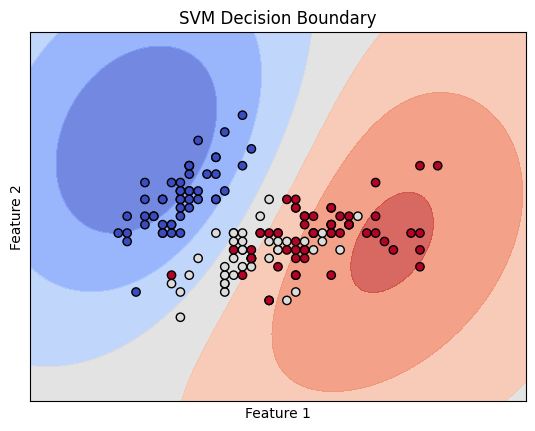

In [4]:
# Muat perpustakaan
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import DecisionBoundaryDisplay

# Buat kisi-kisi jaring
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Sesuaikan masukan agar sesuai dengan jumlah fitur yang diharapkan
# Gunakan keempat fitur untuk prediksi, tetapi visualisasikan hanya dua fitur pertama
grid_points = np.c_[xx.ravel(), yy.ravel(), np.zeros((xx.ravel().shape[0], 2))]

# Plot batasan keputusan menggunakan DecisionBoundaryDisplay
fig, ax = plt.subplots()
disp = DecisionBoundaryDisplay.from_estimator(
    svm_regressor,
    grid_points[:, :2],
    response_method="predict",
    plot_method="contourf",
    cmap=plt.cm.coolwarm,
    alpha=0.8,
    ax=ax
)

# Plot titik datanya
ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', cmap=plt.cm.coolwarm)
ax.set_title("SVM Decision Boundary")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_xlim(xx.min(), xx.max())
ax.set_ylim(yy.min(), yy.max())
ax.set_xticks(())
ax.set_yticks(())
plt.show()


## Fungsi Kernel dan Aplikasinya
Fungsi kernel adalah elemen penting yang memberikan kekuatan pada SVM, memungkinkannya menangani data non-linier secara efektif. Dengan memetakan data asli ke dalam ruang berdimensi lebih tinggi, fungsi kernel memungkinkan SVM menemukan batas keputusan linier di ruang baru ini, yang sesuai dengan batas non-linier di ruang asli.

### Bersiap
Sebelum mengimplementasikan fungsi kernel dengan SVM, pastikan kita telah menginstal pustaka Python yang diperlukan dan kumpulan data dimuat:

In [5]:
# Muat perpustakaan
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Muat kumpulan data
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)


### Bagaimana cara melakukannya
Sekarang mari kita implementasi SVM menggunakan fungsi kernel yang berbeda. Kita sudah menggunakan kernel linier pada contoh pertama, jadi sekarang mari kita gunakan Kernel Polinomial:

In [6]:
# Muat modelnya
svm_poly = SVC(kernel='poly', degree=3)

# Latih modelnya
svm_poly.fit(X_train, y_train)

# Buatlah prediksi
y_pred_poly = svm_poly.predict(X_test)

# Evaluasi modelnya
accuracy_poly = accuracy_score(y_test, y_pred_poly)
report_poly = classification_report(y_test, y_pred_poly, output_dict=True)
report_df_poly = pd.DataFrame(report_poly).transpose()

# Sesuaikan gaya DataFrame
styled_df_poly = (report_df_poly
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print(f"Polynomial Kernel Accuracy: {accuracy_poly:.2f}")
styled_df_poly


Polynomial Kernel Accuracy: 0.96


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,1.000,0.833,0.909,12
2,0.882,1.000,0.938,15
accuracy,0.956,0.956,0.956,1
macro avg,0.961,0.944,0.949,45
weighted avg,0.961,0.956,0.955,45


Sekarang dengan Kernel RBF:

In [7]:
# Muat modelnya
svm_rbf = SVC(kernel='rbf')

# Latih modelnya
svm_rbf.fit(X_train, y_train)

# Buatlah prediksi
y_pred_rbf = svm_rbf.predict(X_test)

# Evaluasi modelnya
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
report_rbf = classification_report(y_test, y_pred_rbf, output_dict=True)
report_df_rbf = pd.DataFrame(report_rbf).transpose()

# Sesuaikan gaya DataFrame
styled_df_rbf = (report_df_rbf
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print(f"RBF Kernel Accuracy: {accuracy_rbf:.2f}")
styled_df_rbf


RBF Kernel Accuracy: 0.91


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.786,0.917,0.846,12
2,0.923,0.800,0.857,15
accuracy,0.911,0.911,0.911,1
macro avg,0.903,0.906,0.901,45
weighted avg,0.917,0.911,0.911,45


Memvisualisasikan batasan keputusan SVM dengan kernel berbeda dapat memberikan wawasan tentang cara mereka mengklasifikasikan data.

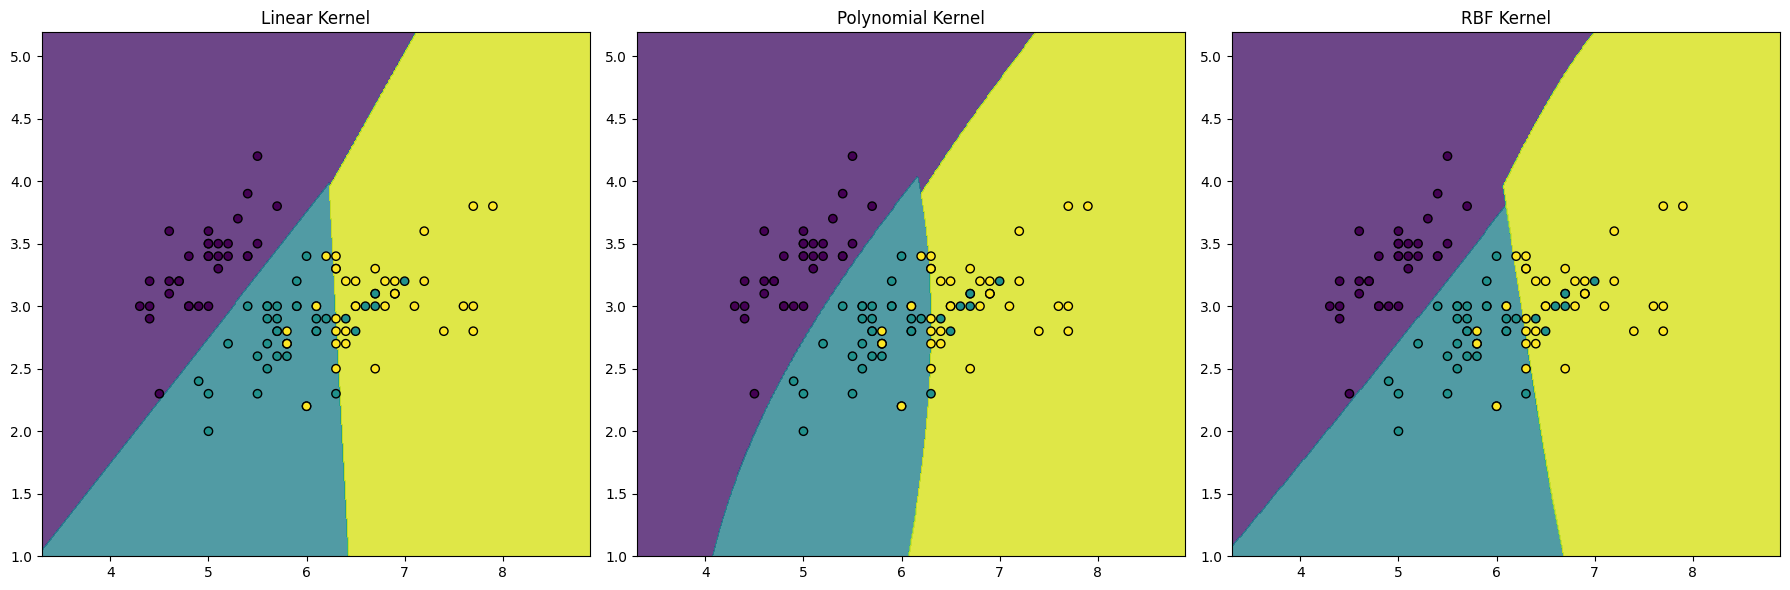

In [8]:
# Buat grid mesh hanya dengan menggunakan dua fitur pertama untuk visualisasi
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Gunakan hanya dua fitur pertama untuk prediksi
X_train_2d = X_train[:, :2]

# Latih model SVM baru hanya dengan menggunakan dua fitur pertama
svm_linear_2d = SVC(kernel='linear').fit(X_train_2d, y_train)
svm_poly_2d = SVC(kernel='poly').fit(X_train_2d, y_train)
svm_rbf_2d = SVC(kernel='rbf').fit(X_train_2d, y_train)

# Memprediksi probabilitas kelas di seluruh grid untuk setiap kernel hanya menggunakan dua fitur pertama
Z_linear = svm_linear_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_poly = svm_poly_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = svm_rbf_2d.predict(np.c_[xx.ravel(), yy.ravel()])

Z_linear = Z_linear.reshape(xx.shape)
Z_poly = Z_poly.reshape(xx.shape)
Z_rbf = Z_rbf.reshape(xx.shape)

# Batasan keputusan plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].contourf(xx, yy, Z_linear, alpha=0.8)
axes[0].scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolors='k', marker='o')
axes[0].set_title("Linear Kernel")

axes[1].contourf(xx, yy, Z_poly, alpha=0.8)
axes[1].scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolors='k', marker='o')
axes[1].set_title("Polynomial Kernel")

axes[2].contourf(xx, yy, Z_rbf, alpha=0.8)
axes[2].scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolors='k', marker='o')
axes[2].set_title("RBF Kernel")

plt.tight_layout()
plt.show()


## Menyetel Parameter SVM
Seperti yang telah kita lihat pada semua model ML lainnya hingga saat ini, penyesuaian dan pengoptimalan hyperparameter juga merupakan langkah penting dalam meningkatkan performa SVM. Dengan menyesuaikan parameter seperti parameter regularisasi (C) dan parameter kernel, kami dapat meningkatkan akurasi dan ketahanan model SVM secara signifikan. Di bagian ini, kita akan menemukan cara menggunakan Grid Search klasik dan teknik Cross-Validation untuk mengoptimalkan model SVM menggunakan scikit-learn.

### Bersiap
Sebelum menyetel parameter SVM, pastikan kita telah menginstal pustaka Python yang diperlukan dan kumpulan data dimuat:

In [9]:
# Muat perpustakaan
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Muat kumpulan data
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Pisahkan kumpulan data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

### Bagaimana cara melakukannya
Sekarang mari kita terapkan penyetelan parameter SVM menggunakan Grid Search dan Cross-Validation:

In [10]:
# Tentukan kisi parameter
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2, 3, 4]
}

# Lakukan Grid Search dengan Cross-Validation
grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Dapatkan hyperparameter dan skor terbaik
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Score: {best_score:.2f}")

# Latih model baru dengan hyperparameter terbaik
best_model = SVC(**best_params)
best_model.fit(X_train, y_train)

# Buat prediksi dengan model terbaik
y_pred = best_model.predict(X_test)

# Evaluasi model terbaik
accuracy = accuracy_score(y_test, y_pred)
report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()

# Sesuaikan gaya DataFrame
styled_report_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print(f"Accuracy: {accuracy:.2f}")
styled_report_df


Best Parameters: {'C': 0.1, 'degree': 4, 'kernel': 'poly'}
Best Cross-Validation Score: 0.99
Accuracy: 0.93


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.909,0.833,0.870,12
2,0.875,0.933,0.903,15
accuracy,0.933,0.933,0.933,1
macro avg,0.928,0.922,0.924,45
weighted avg,0.934,0.933,0.933,45


### Cara kerjanya

Grid Search adalah pendekatan sistematis untuk penyetelan hyperparameter yang melibatkan evaluasi semua kemungkinan kombinasi parameter yang ditentukan dalam grid. Cross-Validation digunakan untuk menilai performa setiap kombinasi, memastikan bahwa model dapat digeneralisasi dengan baik terhadap data yang tidak terlihat.

* **Parameter Regularisasi (C)**: Mengontrol trade-off antara margin dan kesalahan kesalahan klasifikasi. Nilai C yang tinggi berarti model tersebut kurang toleran terhadap kesalahan klasifikasi.

* **Parameter Kernel**: Kernel yang berbeda (misalnya, linier, RBF, polinomial) dan parameternya (misalnya, derajat untuk polinomial, gamma untuk RBF) memengaruhi cara data dipetakan ke dalam ruang berdimensi lebih tinggi.

Memvisualisasikan bagaimana hyperparameter yang berbeda memengaruhi performa model dapat memberikan wawasan tentang proses penyesuaian.

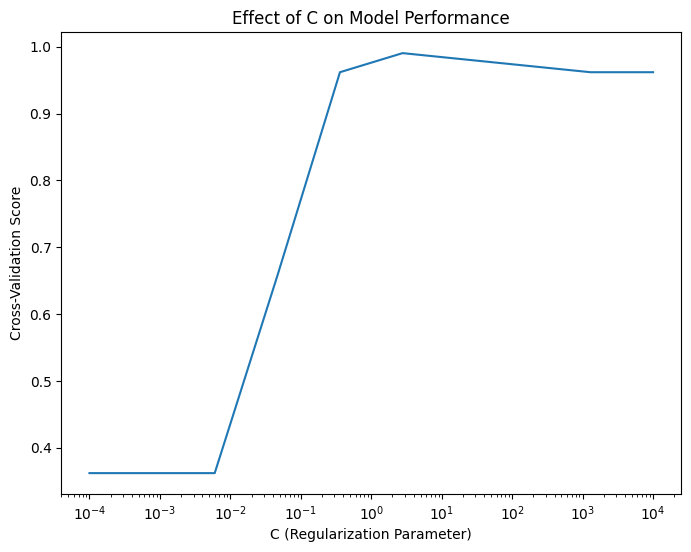

In [11]:
# Lakukan Grid Search dengan rentang nilai C untuk kernel tertentu
param_grid_c = {
    'C': np.logspace(-4, 4, 10),
    'kernel': ['rbf']
}
grid_search_c = GridSearchCV(SVC(), param_grid_c, cv=5)
grid_search_c.fit(X_train, y_train)

# Plot skor Cross-Validation terhadap nilai C
plt.figure(figsize=(8, 6))
plt.plot(grid_search_c.param_grid['C'], grid_search_c.cv_results_['mean_test_score'])
plt.xscale('log')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Cross-Validation Score')
plt.title('Effect of C on Model Performance')
plt.show()


## SVM di Ruang Dimensi Tinggi
SVM sangat efektif dalam menangani data berdimensi tinggi, yang jumlah fiturnya lebih banyak dibandingkan jumlah sampelnya. Misalnya, mungkin Anda mengukur peristiwa langka namun memiliki beberapa instrumen canggih untuk mengumpulkan ratusan titik data tentang peristiwa tersebut begitu peristiwa tersebut terjadi. Kami menyebutnya kumpulan data “lebar”. Pada bagian ini, kita akan melihat lebih dekat bagaimana SVM dapat diterapkan pada data berdimensi tinggi, baik yang dihasilkan secara sintetis maupun dari kumpulan data dunia nyata.

### Bersiap
Sebelum menerapkan SVM ke data berdimensi tinggi, pastikan kita telah menginstal pustaka Python yang diperlukan dan kumpulan data dimuat:

In [12]:
# Muat perpustakaan
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

# Buat kumpulan data sintetis berdimensi tinggi
X, y = make_classification(n_samples=1000, n_features=1000, n_informative=50, n_redundant=0, random_state=2024)

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

### Bagaimana cara melakukannya...
Sekarang mari kita implementasi SVM untuk data berdimensi tinggi.

In [13]:
# Muat modelnya
svm_model = SVC(kernel='linear')

# Latih modelnya
svm_model.fit(X_train, y_train)

# Buatlah prediksi
y_pred = svm_model.predict(X_test)

# Evaluasi modelnya
accuracy = accuracy_score(y_test, y_pred)
report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()

# Sesuaikan gaya DataFrame
styled_report_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print(f"Accuracy: {accuracy:.2f}")
styled_report_df


Accuracy: 0.75


,precision,recall,f1-score,support
0,0.765,0.765,0.765,162
1,0.725,0.725,0.725,138
accuracy,0.747,0.747,0.747,1
macro avg,0.745,0.745,0.745,300
weighted avg,0.747,0.747,0.747,300


### Cara Kerjanya...

SVM menangani data berdimensi tinggi secara efisien dengan memanfaatkan fungsi kernel. Pilihan kernel bergantung pada sifat data dan kompleksitas batasan keputusan.
* **Kernel Linier**: Cocok untuk data yang dapat dipisahkan secara linier atau ketika jumlah fiturnya banyak.
* **Kernel Non-Linear (mis., RBF, Polinomial)**: Berguna untuk data yang dapat dipisahkan secara non-linier, memungkinkan SVM menemukan batasan keputusan yang kompleks.

Memvisualisasikan data berdimensi tinggi secara langsung memang menantang, namun kita dapat menggunakan teknik Dimensionality Reduction seperti PCA untuk memproyeksikan data ke ruang berdimensi lebih rendah untuk visualisasi. Untuk memvisualisasikan data menggunakan PCA:

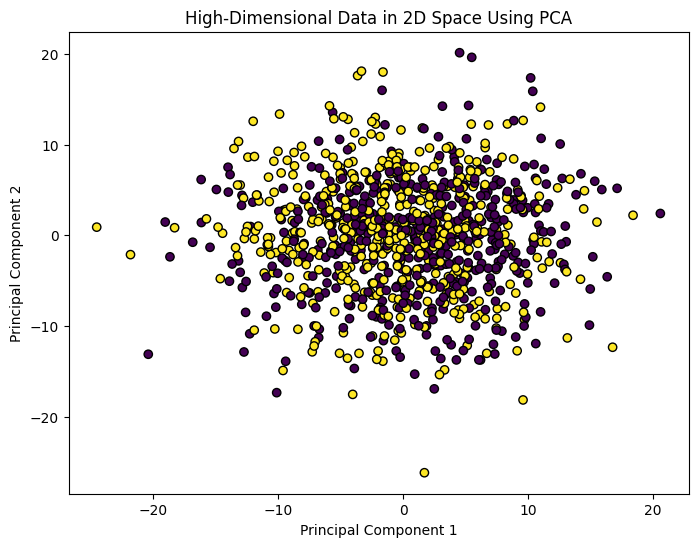

In [14]:
# Impor PCA dari sklearn.decomposition
from sklearn.decomposition import PCA

# Terapkan PCA untuk mengurangi dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot data yang telah direduksi
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k', marker='o')
plt.title("High-Dimensional Data in 2D Space Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


## Mengevaluasi Model SVM
Mengevaluasi performa model Support Vector Machine (SVM) sangat penting untuk memahami seberapa baik model tersebut menggeneralisasi data baru. Di bagian ini, kita akan mengeksplorasi metrik utama untuk mengevaluasi model SVM, termasuk kurva akurasi, presisi, perolehan, dan ROC. Dengan menerapkan metrik ini, kami dapat menilai kekuatan dan kelemahan model SVM kami dan membuat keputusan yang tepat mengenai penerapannya.

### Bersiap
Sebelum mengevaluasi model SVM, pastikan kita telah menginstal pustaka Python yang diperlukan dan kumpulan data dimuat:

In [15]:
# Muat perpustakaan
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report, roc_curve, auc
import pandas as pd
import matplotlib.pyplot as plt

# Muat kumpulan data
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)


### Bagaimana Melakukannya...
Sekarang mari kita implementasi SVM dan evaluasi kinerjanya menggunakan berbagai metrik.

In [16]:
# Muat modelnya
svm_model = SVC(kernel='linear', probability=True)

# Latih modelnya
svm_model.fit(X_train, y_train)

# Buatlah prediksi
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]

# Evaluasi modelnya
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Sesuaikan gaya DataFrame
styled_report_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print(f"Accuracy: {accuracy:.2f}")
styled_report_df


Accuracy: 0.75


,precision,recall,f1-score,support
0,0.926,0.940,0.933,67
1,0.961,0.952,0.957,104
accuracy,0.947,0.947,0.947,1
macro avg,0.944,0.946,0.945,171
weighted avg,0.948,0.947,0.947,171


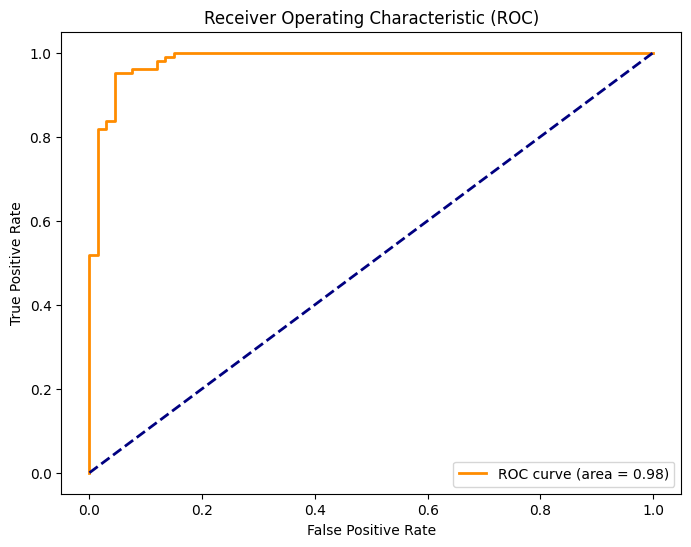

In [17]:
# Plot kurva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


## Cara Kerjanya...

Mengevaluasi model SVM melibatkan penilaian kinerjanya menggunakan berbagai metrik:
• Akurasi: Mengukur proporsi instance yang diklasifikasikan dengan benar.
• Presisi: Mengukur proporsi positif sebenarnya di antara seluruh kejadian positif yang diprediksi.
• Ingat: Mengukur proporsi positif sebenarnya di antara semua kejadian positif aktual.
• Skor F1: Nilai rata-rata yang harmonis antara presisi dan perolehan, memberikan ukuran yang seimbang dari keduanya.
• Kurva ROC: Memplot rasio positif sebenarnya terhadap rasio positif palsu pada ambang batas yang berbeda, sehingga memberikan gambaran menyeluruh tentang kinerja model di semua ambang batas yang memungkinkan.
• AUC (Area Di Bawah Kurva): Mengukur kemampuan keseluruhan model untuk membedakan kelas positif dan negatif.

## Latihan Praktis dengan SVM

Di bagian akhir ini, kita akan melakukan latihan praktis yang melibatkan pembuatan, penyesuaian, dan evaluasi model SVM pada berbagai kumpulan data. Latihan-latihan ini dirancang untuk memperkuat konsep-konsep yang dipelajari sepanjang bab ini dan menunjukkan bagaimana menerapkan SVM secara efektif dalam berbagai skenario. Di akhir bagian ini, kita akan memiliki pengalaman langsung yang dapat dimanfaatkan dalam proyek ML kita sendiri.

### Latihan 1: Membangun Classifier SVM Sederhana
Dalam latihan ini, kita akan membuat Classifier SVM sederhana menggunakan dataset Iris.

In [18]:
# Muat perpustakaan
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Muat kumpulan data
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Membuat dan melatih Classifier SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Buatlah prediksi
y_pred = svm_model.predict(X_test)

# Evaluasi kinerja
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)


Accuracy: 0.93
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.91      0.83      0.87        12
           2       0.88      0.93      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.92      0.92        45
weighted avg       0.93      0.93      0.93        45



### Latihan 2: Menyesuaikan Parameter SVM dengan Pencarian Grid
Dalam latihan ini, kita akan menyetel parameter SVM menggunakan Grid Search pada dataset Kanker Payudara.

In [19]:
# Muat perpustakaan
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Muat kumpulan data
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Tentukan hyperparameter untuk Grid Search
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2, 3, 4]
}

# Lakukan Grid Search dengan Cross-Validation
grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)


# Latih model baru dengan hyperparameter terbaik
best_model = SVC(**grid_search.best_params_)
best_model.fit(X_train, y_train)

# Buat prediksi dengan model terbaik
y_pred_best = best_model.predict(X_test)

# Evaluasi model terbaik
accuracy_best = accuracy_score(y_test, y_pred_best)
report_best = classification_report(y_test, y_pred_best)
print(f"Best Model Accuracy: {accuracy_best:.2f}")
print("Best Model Classification Report:")
print(report_best)


Best Model Accuracy: 0.95
Best Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93        67
           1       0.96      0.95      0.96       104

    accuracy                           0.95       171
   macro avg       0.94      0.95      0.94       171
weighted avg       0.95      0.95      0.95       171



### Latihan 3: Memvisualisasikan Batasan Keputusan SVM
Dalam latihan ini, kami akan memvisualisasikan batasan keputusan model SVM yang dilatih pada kumpulan data sintetis.

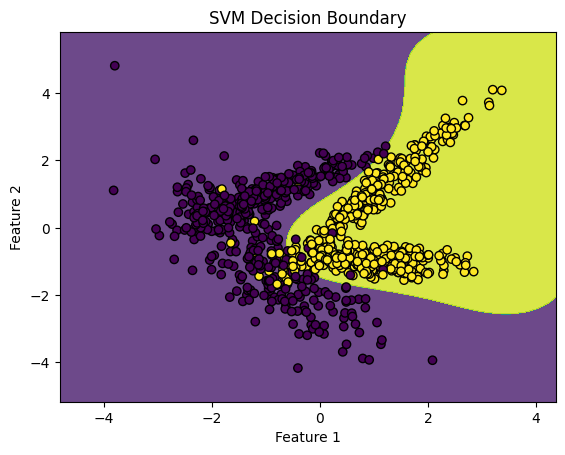

In [20]:
# Memuat perpustakaan untuk visualisasi dan pembuatan kumpulan data
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Buat kumpulan data sintetis untuk klasifikasi biner
X, y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_informative=2, n_redundant=0, random_state=2024)

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Membuat dan melatih model SVM
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

# Buat grid mesh untuk merencanakan batas-batas keputusan
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Memprediksi probabilitas kelas di seluruh grid
Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Batasan keputusan plot
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
plt.title("SVM Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


### Ringkasan dan Pandangan (Summary and Outlook)

#### 1. Ringkasan Bab
Dalam bab ini, kita telah mempelajari Support Vector Machine (SVM):
* **Konsep Batas Keputusan Margin Maksimum:** Mencari garis/hiperbidang pemisah yang memiliki jarak terjauh dari sampel terdekat (support vectors).
* **Trik Kernel:** Menggunakan kernel RBF (Radial Basis Function) dan Polinomial untuk memetakan data non-linier ke ruang dimensi lebih tinggi sehingga dapat dipisahkan secara linier.
* **Penyetelan Hyperparameter:** Memahami peran parameter regulasi $C$ dan parameter kernel $\gamma$ (gamma) terhadap bias-varians model.

#### 2. Pandangan ke Depan
SVM sangat tangguh untuk dataset dengan dimensi tinggi, tetapi cukup lambat untuk dataset berskala sangat besar. Di **Bab 8**, kita akan mengeksplorasi algoritma non-parametrik yang sangat populer untuk data tabular dan tidak terpengaruh oleh penskalaan data, yaitu algoritma berbasis pohon keputusan (*Decision Trees*) dan metode ensemble.